In [1]:
import os
import sys
import warnings

sys.path.append(os.path.abspath("../scripts"))
warnings.filterwarnings("ignore")


import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = "retina"
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12


from data_preprocessing import preprocess_for_nn
from boosting_models import run_lr_tuning, run_catboost_tuning, run_lgbm_tuning
from deep_model import TabularDataset, TABMLP, train, evaluate
from metric_utils import bootstrap_metrics

## Датасет [Heart](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction)

In [2]:
import kagglehub

path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction") + "/heart.csv"

df = pd.read_csv(path)
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
X = df.drop(columns=["HeartDisease"])
y = df["HeartDisease"]
le = LabelEncoder()
y = le.fit_transform(y)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y, shuffle=True)
X_test, X_valid, y_test, y_valid = train_test_split(X_test, y_test, test_size=0.5, random_state=0, stratify=y_test, shuffle=True)

In [5]:
categorical_features = ["Sex", "ChestPainType", "FastingBS", "RestingECG", "ExerciseAngina", "ST_Slope"]
numerical_features = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
column_transformer = ColumnTransformer([
        ("ohe", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("scaling", StandardScaler(), numerical_features)
])

In [6]:
model_lr = run_lr_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_lr = model_lr.predict(X_test)
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]
metrics_lr = bootstrap_metrics(y_test, y_pred_lr, y_prob_lr)

[I 2025-04-21 17:41:34,892] A new study created in memory with name: logistic_regression_optimization


[I 2025-04-21 17:41:34,923] Trial 0 finished with value: 0.9512195121951219 and parameters: {'penalty': 'l1', 'C': 10}. Best is trial 0 with value: 0.9512195121951219.
[I 2025-04-21 17:41:34,938] Trial 1 finished with value: 0.8866571018651364 and parameters: {'penalty': 'l2', 'C': 0.001}. Best is trial 0 with value: 0.9512195121951219.
[I 2025-04-21 17:41:34,950] Trial 2 finished with value: 0.5 and parameters: {'penalty': 'l1', 'C': 1e-05}. Best is trial 0 with value: 0.9512195121951219.
[I 2025-04-21 17:41:34,965] Trial 3 finished with value: 0.8127690100430416 and parameters: {'penalty': 'l1', 'C': 0.01}. Best is trial 0 with value: 0.9512195121951219.
[I 2025-04-21 17:41:34,982] Trial 4 finished with value: 0.9507412721186035 and parameters: {'penalty': 'l2', 'C': 100}. Best is trial 0 with value: 0.9512195121951219.
[I 2025-04-21 17:41:34,994] Trial 5 finished with value: 0.8761358201817312 and parameters: {'penalty': 'l2', 'C': 0.0001}. Best is trial 0 with value: 0.951219512195

In [7]:
model_cb = run_catboost_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_cb  = model_cb.predict(X_test)
y_prob_cb  = model_cb.predict_proba(X_test)[:, 1]
metrics_cb = bootstrap_metrics(y_test, y_pred_cb, y_prob_cb)

[I 2025-04-21 17:41:38,404] A new study created in memory with name: catboost_optimization
[I 2025-04-21 17:41:38,812] Trial 0 finished with value: 0.9043519846963176 and parameters: {'depth': 2, 'learning_rate': 0.1, 'l2_leaf_reg': 1.0}. Best is trial 0 with value: 0.9043519846963176.
[I 2025-04-21 17:41:39,171] Trial 1 finished with value: 0.9134385461501674 and parameters: {'depth': 2, 'learning_rate': 0.1, 'l2_leaf_reg': 3.0}. Best is trial 1 with value: 0.9134385461501674.
[I 2025-04-21 17:41:40,230] Trial 2 finished with value: 0.9569583931133429 and parameters: {'depth': 6, 'learning_rate': 0.01, 'l2_leaf_reg': 1.0}. Best is trial 2 with value: 0.9569583931133429.
[I 2025-04-21 17:41:41,317] Trial 3 finished with value: 0.9545671927307507 and parameters: {'depth': 6, 'learning_rate': 0.001, 'l2_leaf_reg': 6.0}. Best is trial 2 with value: 0.9569583931133429.
[I 2025-04-21 17:41:44,088] Trial 4 finished with value: 0.9478718316594932 and parameters: {'depth': 8, 'learning_rate': 

In [8]:
model_lgbm = run_lgbm_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_lgbm = model_lgbm.predict(X_test)
y_prob_lgbm = model_lgbm.predict_proba(X_test)[:, 1]
metrics_lgbm = bootstrap_metrics(y_test, y_pred_lgbm, y_prob_lgbm)

[I 2025-04-21 17:42:20,287] A new study created in memory with name: lightgbm_optimization
[I 2025-04-21 17:42:20,717] Trial 0 finished with value: 0.9091343854615017 and parameters: {'num_leaves': 8, 'reg_alpha': 0.0001, 'reg_lambda': 0.001, 'learning_rate': 0.3}. Best is trial 0 with value: 0.9091343854615017.
[I 2025-04-21 17:42:20,835] Trial 1 finished with value: 0.9555236728837877 and parameters: {'num_leaves': 2, 'reg_alpha': 1.0, 'reg_lambda': 0.01, 'learning_rate': 0.1}. Best is trial 1 with value: 0.9555236728837877.
[I 2025-04-21 17:42:21,671] Trial 2 finished with value: 0.9387852702056432 and parameters: {'num_leaves': 16, 'reg_alpha': 1e-07, 'reg_lambda': 0.01, 'learning_rate': 0.01}. Best is trial 1 with value: 0.9555236728837877.
[I 2025-04-21 17:42:23,097] Trial 3 finished with value: 0.9311334289813487 and parameters: {'num_leaves': 1024, 'reg_alpha': 0.1, 'reg_lambda': 1e-08, 'learning_rate': 0.03}. Best is trial 1 with value: 0.9555236728837877.
[I 2025-04-21 17:42:

In [9]:
X_train, X_valid, X_test = preprocess_for_nn(X_train, X_valid, X_test, categorical_features, numerical_features)

In [10]:
trainset = TabularDataset(X_train, y_train, categorical_features)
valset = TabularDataset(X_valid, y_valid, categorical_features)
testset  = TabularDataset(X_test, y_test, categorical_features)

batch_size = 256
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(valset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(testset, batch_size=batch_size, shuffle=False)

In [11]:
cat_dims = [int(X_train[col].nunique()) for col in categorical_features]
emb_dims = [(x, min(50, (x + 1) // 2)) for x in cat_dims]

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


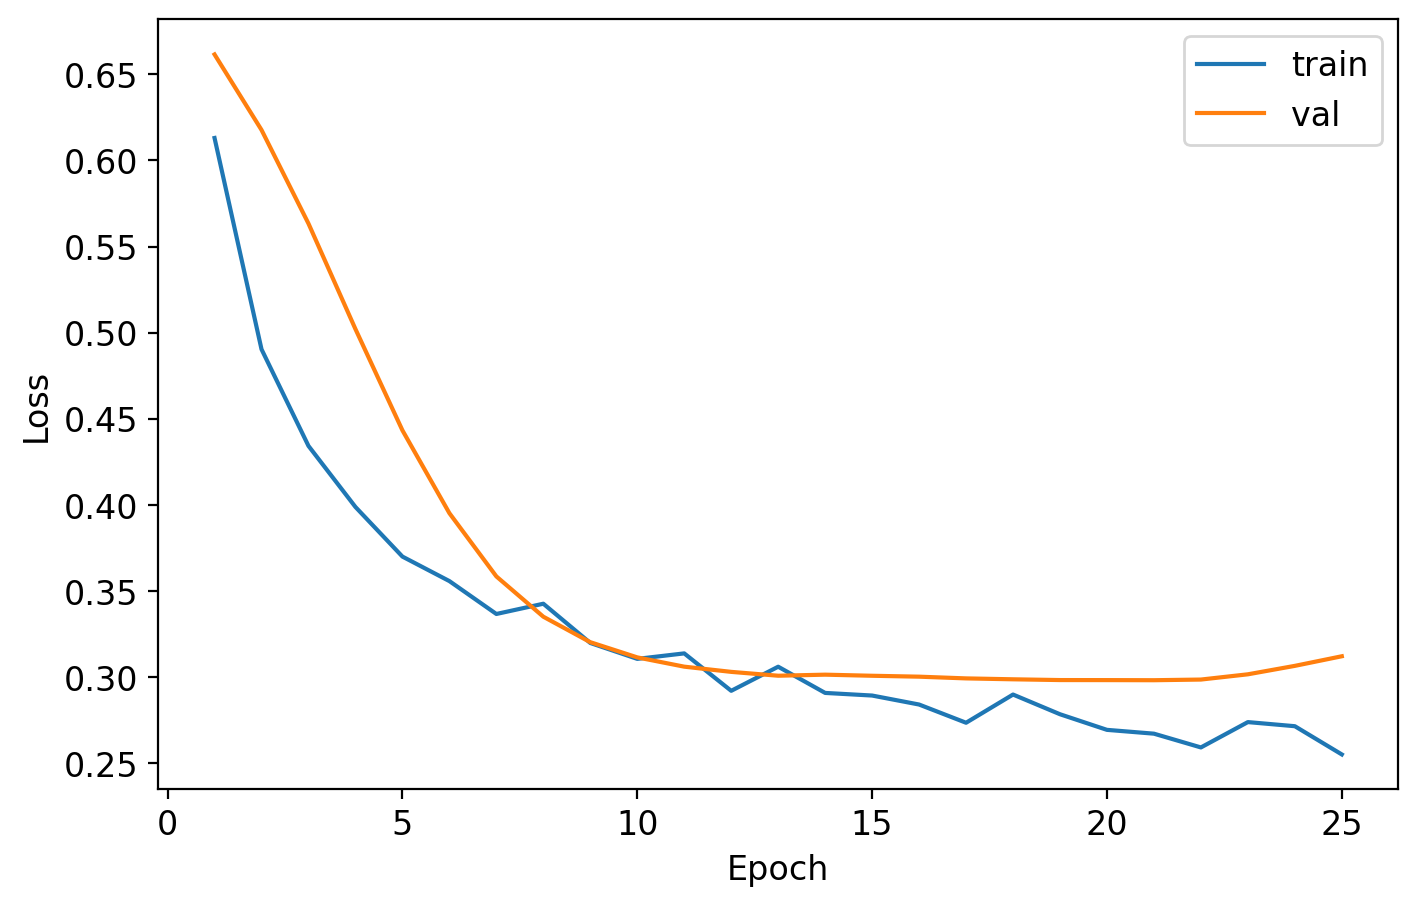

Epoch 25: train loss = 0.2552; valid loss = 0.3122


In [13]:
net = TABMLP(len(numerical_features), emb_dims).to(device)
optimizer = optim.Adam(net.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

train(net, optimizer, 25, train_loader, val_loader, criterion, device)

In [14]:
y_true, y_prob, y_pred = evaluate(net, test_loader, device)
metrics_nn = bootstrap_metrics(y_true, y_pred, y_prob)

In [15]:
res = pd.DataFrame([{"model": "Logistic regression"} | metrics_lr, {"model": "CatBoost"} | metrics_cb, {"model": "LightGBM"} | metrics_lgbm, {"model": "TABMLP"} | metrics_nn])
res

,model,ROC-AUC,F1,Accuracy,Precision,Recall
0,Logistic regression,0.9442±0.0209,0.8738±0.0358,0.8695±0.0348,0.9339±0.0365,0.8230±0.0529
1,CatBoost,0.9590±0.0179,0.9052±0.0311,0.9010±0.0305,0.9556±0.0305,0.8615±0.0489
2,LightGBM,0.9371±0.0234,0.8649±0.0372,0.8588±0.0362,0.9138±0.0411,0.8230±0.0529
3,TABMLP,0.9727±0.0127,0.9061±0.0304,0.9020±0.0298,0.9570±0.0284,0.8620±0.0483
